# **U2210251 ; params - 11.2 million ; f1 - 9.17** 

#octupler

In [11]:
import os
import shutil
import random
from PIL import Image, ImageOps
from tqdm.notebook import tqdm

# ==========================================
# CONFIGURATION
# ==========================================
INPUT_DIR = '/kaggle/input/images-v3/images'   # Where your original folders are
OUTPUT_DIR = 'dataset_augmented_8x' # New Massive Folder

# Clean start
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

# Create Structure
os.makedirs(os.path.join(OUTPUT_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'validation'), exist_ok=True)

print(f"🚀 STARTING 8x DATASET EXPANSION...")
print(f"   Source: {INPUT_DIR}")
print(f"   Target: {OUTPUT_DIR}")

# Get class names
classes = [d for d in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, d))]
classes = [c for c in classes if not c.startswith('.')] # Skip hidden files

for class_name in classes:
    print(f"\nProcessing Class: {class_name}...")

    # Create subfolders
    os.makedirs(os.path.join(OUTPUT_DIR, 'train', class_name), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, 'validation', class_name), exist_ok=True)

    # Get Images
    src_path = os.path.join(INPUT_DIR, class_name)
    images = [f for f in os.listdir(src_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]

    # 1. SPLIT FIRST (Crucial for Integrity)
    random.seed(42)
    random.shuffle(images)

    split_idx = int(len(images) * 0.8)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    # 2. HANDLE VALIDATION (Pure Copy)
    print(f"   - Moving {len(val_imgs)} images to Validation (Untouched)")
    for img_name in val_imgs:
        shutil.copy(
            os.path.join(src_path, img_name),
            os.path.join(OUTPUT_DIR, 'validation', class_name, img_name)
        )

    # 3. HANDLE TRAINING (The 8x Generator)
    print(f"   - Generating {len(train_imgs) * 8} images for Training...")

    for img_name in tqdm(train_imgs, leave=False):
        full_path = os.path.join(src_path, img_name)

        try:
            with Image.open(full_path) as img:
                img = img.convert('RGB')

                # We will generate 4 rotations, and for each rotation, we also save a flipped version.
                # Angles: 0, 90, 180, 270

                angles = [0, 90, 180, 270]

                for angle in angles:
                    # 1. Rotate
                    if angle == 0:
                        rot_img = img
                    else:
                        rot_img = img.rotate(angle, expand=True)

                    # Save Rotated
                    rot_name = f"rot{angle}_{img_name}"
                    rot_img.save(os.path.join(OUTPUT_DIR, 'train', class_name, rot_name))

                    # 2. Flip the Rotated version
                    flip_img = ImageOps.mirror(rot_img)

                    # Save Flipped
                    flip_name = f"flip_rot{angle}_{img_name}"
                    flip_img.save(os.path.join(OUTPUT_DIR, 'train', class_name, flip_name))

        except Exception as e:
            print(f"⚠️ Error processing {img_name}: {e}")

print(f"\n✅ DONE! Dataset expanded 8x in '{OUTPUT_DIR}'")

🚀 STARTING 8x DATASET EXPANSION...
   Source: /kaggle/input/images-v3/images
   Target: dataset_augmented_8x

Processing Class: Belly-Rot...
   - Moving 32 images to Validation (Untouched)
   - Generating 1024 images for Training...


  0%|          | 0/128 [00:00<?, ?it/s]


Processing Class: Fresh-Leaf...
   - Moving 32 images to Validation (Untouched)
   - Generating 1024 images for Training...


  0%|          | 0/128 [00:00<?, ?it/s]


Processing Class: Bacterial-Wilt...
   - Moving 32 images to Validation (Untouched)
   - Generating 1024 images for Training...


...


Processing Class: Gummy-Stem-Blight...
   - Moving 32 images to Validation (Untouched)
   - Generating 1024 images for Training...


  0%|          | 0/128 [00:00<?, ?it/s]


Processing Class: Downy-Mildew...
   - Moving 32 images to Validation (Untouched)
   - Generating 1024 images for Training...


  0%|          | 0/128 [00:00<?, ?it/s]


✅ DONE! Dataset expanded 8x in 'dataset_augmented_8x'


#Nuclear Custom Resnet-Attention Deep Model

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np

# ==========================================
# 1. DEFINE CUSTOM RESNET ARCHITECTURE
# ==========================================
def squeeze_excite_block(input_tensor, ratio=16):
    init = input_tensor
    filters = init.shape[-1]
    se = layers.GlobalAveragePooling2D()(init)
    se = layers.Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = layers.Dense(filters, activation='sigmoid', use_bias=False)(se)
    return layers.Multiply()([init, se])

def resnet_block(input_tensor, filters, stride=1):
    x = input_tensor
    # Path A
    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same',
                      kernel_initializer='he_normal', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same',
                      kernel_initializer='he_normal', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x) # Attention inside ResBlock

    # Path B (Shortcut)
    shortcut = input_tensor
    if stride > 1 or input_tensor.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_8x(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Entry
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # ResNet Body (18-Layer style)
    x = resnet_block(x, 64)
    x = resnet_block(x, 64)

    x = resnet_block(x, 128, stride=2)
    x = resnet_block(x, 128)

    x = resnet_block(x, 256, stride=2)
    x = resnet_block(x, 256)

    x = resnet_block(x, 512, stride=2)
    x = resnet_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs, name="ResNet_8x_Attention")

print("✅ Model Architecture Defined.")

✅ Model Architecture Defined.


#Training

In [22]:
# ==========================================
# 2. DATA LOADING (8x)
# ==========================================
DATA_PATH = 'dataset_augmented_8x'
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

# No geometric augmentation in generator (already did it offline)
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    width_shift_range=0.1,  # Keep slight shift
    height_shift_range=0.1, # Keep slight shift
    zoom_range=0.1,         # Keep slight zoom
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    os.path.join(DATA_PATH, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(DATA_PATH, 'validation'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ==========================================
# 3. COMPILE & TRAIN
# ==========================================
model = build_resnet_8x((256, 256, 3), train_generator.num_classes)

optimizer = optimizers.Adam(learning_rate=0.0005)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# Callbacks
checkpoint = callbacks.ModelCheckpoint('best_resnet_8x.keras',
                                       monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

# Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=validation_generator,
    callbacks=[checkpoint, reduce_lr, early_stop],
    class_weight=class_weight_dict
)

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import f1_score, classification_report, accuracy_score
import gc

# ==========================================
# 1. CONFIGURATION (Standard 256 only)
# ==========================================
DATA_PATH = 'dataset_augmented_8x' 
IMG_SIZE = (256, 256)  # <--- Sticking to the standard size
BATCH_SIZE = 32

# Filenames of your two best runs
# (Make sure these files actually exist!)
MODEL_A_PATH = 'best_resnet_8x.keras'      # The Deep ResNet
MODEL_B_PATH = 'best_8x_model.keras'       # The Standard Attention CNN (from earlier)

# ==========================================
# 2. PREDICTION FUNCTION
# ==========================================
def get_preds(model_path, name):
    print(f"\n🔄 Loading {name}...")
    
    if not os.path.exists(model_path):
        print(f"⚠️ WARNING: Could not find {model_path}")
        print("   Skipping this model...")
        return None

    # Load
    model = tf.keras.models.load_model(model_path)
    
    # Generators
    val_gen = ImageDataGenerator(rescale=1.0/255.0)
    tta_gen = ImageDataGenerator(rescale=1.0/255.0, horizontal_flip=True)
    
    # Standard
    gen_std = val_gen.flow_from_directory(
        os.path.join(DATA_PATH, 'validation'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    # TTA
    gen_tta = tta_gen.flow_from_directory(
        os.path.join(DATA_PATH, 'validation'),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False
    )
    
    print(f"   Predicting...")
    p_std = model.predict(gen_std, verbose=1)
    p_tta = model.predict(gen_tta, verbose=1)
    
    # Average
    avg_preds = (0.5 * p_std) + (0.5 * p_tta)
    
    # Cleanup
    true_y = gen_std.classes
    labels = list(gen_std.class_indices.keys())
    del model
    tf.keras.backend.clear_session()
    gc.collect()
    
    return avg_preds, true_y, labels

# ==========================================
# 3. RUN ENSEMBLE
# ==========================================

# Get Predictions
preds_res, true_y, labels = get_preds(MODEL_A_PATH, "ResNet-18")
preds_cnn, _, _ = get_preds(MODEL_B_PATH, "Attention-CNN")

if preds_res is not None and preds_cnn is not None:
    print("\n⚔️ COMBINING PREDICTIONS (256x256)...")
    
    # Average them equally (Or weight the better one higher)
    final_preds = (0.5 * preds_res) + (0.5 * preds_cnn)
    
    y_pred = np.argmax(final_preds, axis=1)
    
    # Score
    acc = accuracy_score(true_y, y_pred)
    f1 = f1_score(true_y, y_pred, average='weighted')
    
    print(f"\n🏆 FINAL ENSEMBLE RESULT:")
    print(f"   Accuracy: {acc:.5f}")
    print(f"   F1 Score: {f1:.5f}")
    print("\n" + classification_report(true_y, y_pred, target_names=labels))

elif preds_res is not None:
    print("⚠️ Only ResNet was found. Showing ResNet scores only.")
    y_pred = np.argmax(preds_res, axis=1)
    print(classification_report(true_y, y_pred, target_names=labels))

elif preds_cnn is not None:
    print("⚠️ Only CNN was found. Showing CNN scores only.")
    y_pred = np.argmax(preds_cnn, axis=1)
    print(classification_report(true_y, y_pred, target_names=labels))


🔄 Loading ResNet-18...
Found 256 images belonging to 8 classes.
Found 256 images belonging to 8 classes.
   Predicting...
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 513ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 633ms/step

🔄 Loading Attention-CNN...
Found 256 images belonging to 8 classes.
Found 256 images belonging to 8 classes.
   Predicting...
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 500ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 616ms/step

⚔️ COMBINING PREDICTIONS (256x256)...

🏆 FINAL ENSEMBLE RESULT:
   Accuracy: 0.91797
   F1 Score: 0.91798

                   precision    recall  f1-score   support

      Anthracnose       0.76      0.78      0.77        32
   Bacterial-Wilt       0.91      0.97      0.94        32
        Belly-Rot       1.00      1.00      1.00        32
     Downy-Mildew       0.93      0.84      0.89        32
   Fresh-Cucumber       1.00      1.00      1.00        32
       Fresh-Leaf       0.91      0.91      0.91        32
Gummy-Stem-Blight       0.84      0.84      0.84        32
Pythium-Fruit

Confusion matrix

🔄 Loading Model: best_resnet_8x.keras...
Found 256 images belonging to 8 classes.
📊 Calculating Confusion Matrix...


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 508ms/step


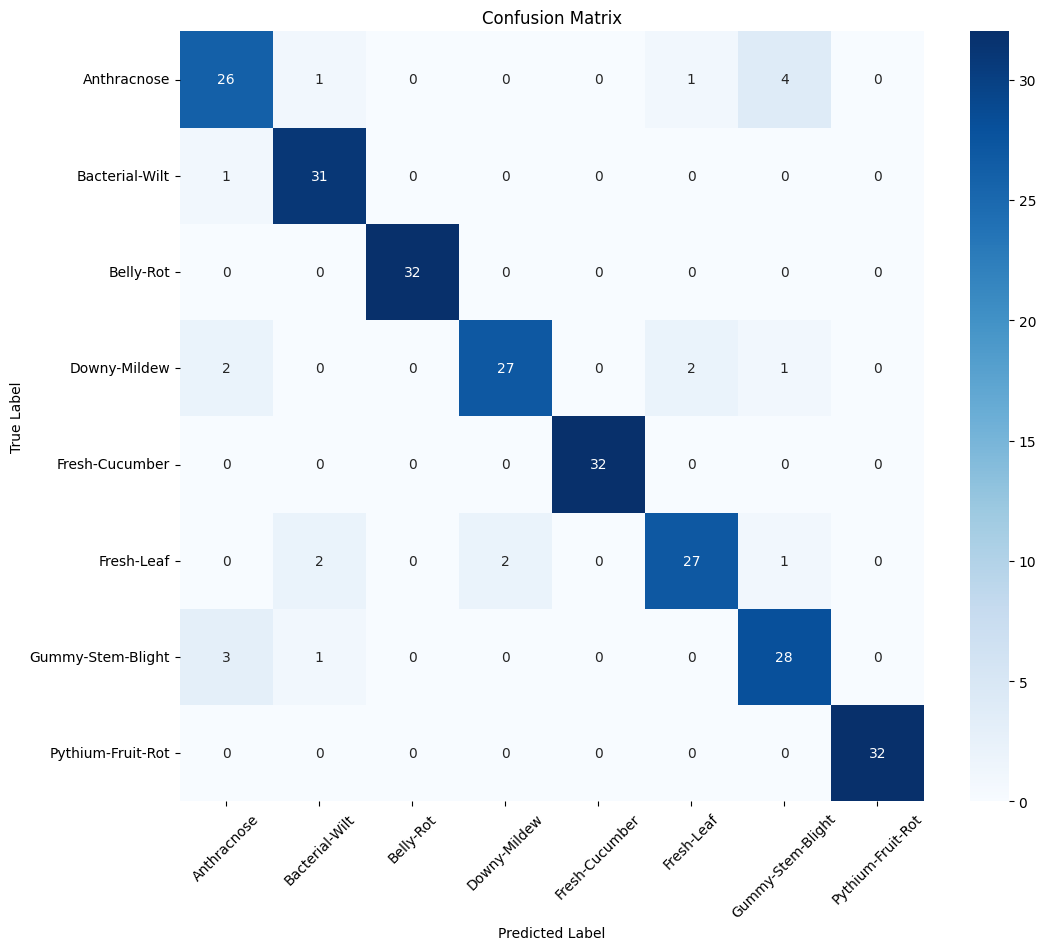

In [24]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# ==========================================
# 1. CONFIGURATION
# ==========================================
# ⚠️ Make sure this points to your current best model
MODEL_PATH = 'best_resnet_8x.keras' 
# OR 'best_hd_model.keras', whichever you want to test

DATA_PATH = 'dataset_augmented_8x' # Your data folder
IMG_SIZE = (256, 256) # Ensure this matches what you trained on!

# ==========================================
# 2. PREPARATION
# ==========================================
print(f"🔄 Loading Model: {MODEL_PATH}...")
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Model file not found: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH)

# Create Generator for Confusion Matrix (No Shuffle!)
val_datagen = ImageDataGenerator(rescale=1.0/255.0)
val_generator = val_datagen.flow_from_directory(
    os.path.join(DATA_PATH, 'validation'),
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False # <--- Critical for Confusion Matrix
)

class_names = list(val_generator.class_indices.keys())

# ==========================================
# 3. GENERATE CONFUSION MATRIX
# ==========================================
print("📊 Calculating Confusion Matrix...")
preds = model.predict(val_generator, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix')
plt.xticks(rotation=45)
plt.show()



Random images from test set

🎲 Picking 4 Random Images...


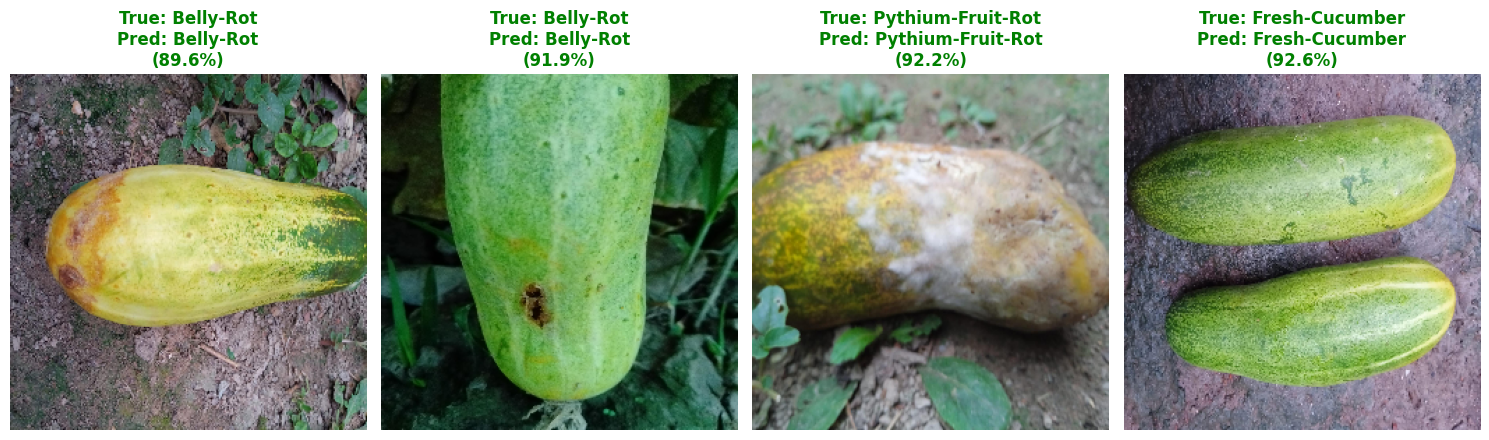

In [25]:
# ==========================================
# 4. SHOW 4 RANDOM IMAGES
# ==========================================
print("🎲 Picking 4 Random Images...")

# Gather all validation image paths
val_dir = os.path.join(DATA_PATH, 'validation')
all_image_paths = []
for cls in class_names:
    cls_folder = os.path.join(val_dir, cls)
    for img_name in os.listdir(cls_folder):
        all_image_paths.append((os.path.join(cls_folder, img_name), cls))

# Pick 4 random ones
selected_images = random.sample(all_image_paths, 4)

plt.figure(figsize=(15, 5))

for i, (img_path, true_label) in enumerate(selected_images):
    # Load and Preprocess
    img = load_img(img_path, target_size=IMG_SIZE)
    x = img_to_array(img)
    x = x / 255.0
    x = np.expand_dims(x, axis=0)
    
    # Predict
    p = model.predict(x, verbose=0)
    pred_idx = np.argmax(p)
    pred_label = class_names[pred_idx]
    confidence = np.max(p)
    
    # Color code the title (Green if correct, Red if wrong)
    color = 'green' if true_label == pred_label else 'red'
    
    # Plot
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}\n({confidence:.1%})", color=color, fontweight='bold')

plt.tight_layout()
plt.show()